In [61]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
import warnings
warnings.filterwarnings('ignore')
# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv


In [62]:
data = pd.read_csv('/kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv')
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [63]:
data.shape

(7043, 21)

In [64]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [65]:
for col in data.columns:
    print(col, data[col].unique())

customerID ['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK']
gender ['Female' 'Male']
SeniorCitizen [0 1]
Partner ['Yes' 'No']
Dependents ['No' 'Yes']
tenure [ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26  0
 39]
PhoneService ['No' 'Yes']
MultipleLines ['No phone service' 'No' 'Yes']
InternetService ['DSL' 'Fiber optic' 'No']
OnlineSecurity ['No' 'Yes' 'No internet service']
OnlineBackup ['Yes' 'No' 'No internet service']
DeviceProtection ['No' 'Yes' 'No internet service']
TechSupport ['No' 'Yes' 'No internet service']
StreamingTV ['No' 'Yes' 'No internet service']
StreamingMovies ['No' 'Yes' 'No internet service']
Contract ['Month-to-month' 'One year' 'Two year']
PaperlessBilling ['Yes' 'No']
PaymentMethod ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (a

In [66]:
data.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [67]:
data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce')
data.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [68]:
data['TotalCharges'].fillna(data['TotalCharges'].median(), inplace=True)
data.drop('customerID', axis=1, inplace=True)
data.duplicated().sum()
data.shape

(7043, 20)

(array([0, 1]), [Text(0, 0, 'No'), Text(1, 0, 'Yes')])

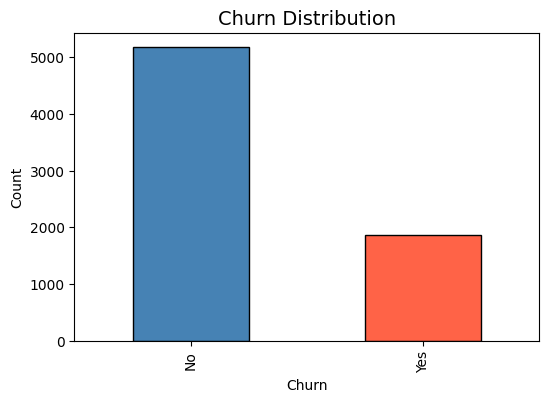

In [69]:
import matplotlib.pyplot as plt
plt.figure(figsize=(6,4))
data['Churn'].value_counts().plot(kind='bar',color=['steelblue','tomato'],edgecolor='black')
plt.title('Churn Distribution', fontsize=14)
plt.xlabel('Churn')
plt.ylabel('Count')
plt.xticks()

In [70]:
data['Churn'].value_counts([0])*100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

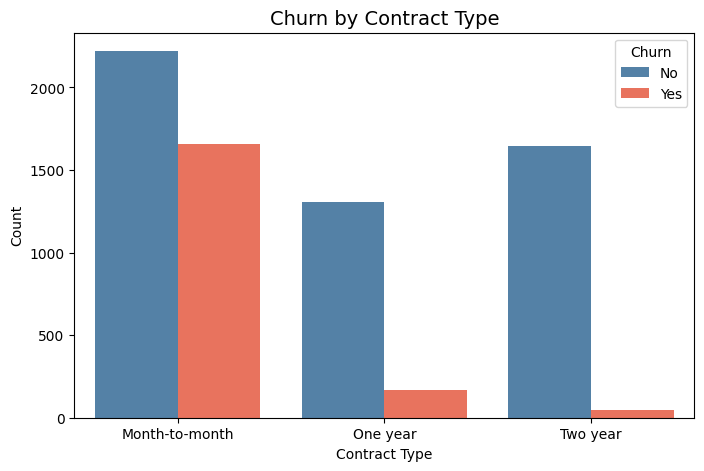

In [71]:
import seaborn as sns
plt.figure(figsize=(8,5))
sns.countplot(data=data, x='Contract', hue='Churn',
              palette=['steelblue','tomato'])
plt.title('Churn by Contract Type', fontsize=14)
plt.xlabel('Contract Type')
plt.ylabel('Count')
plt.legend(title='Churn')
plt.show()

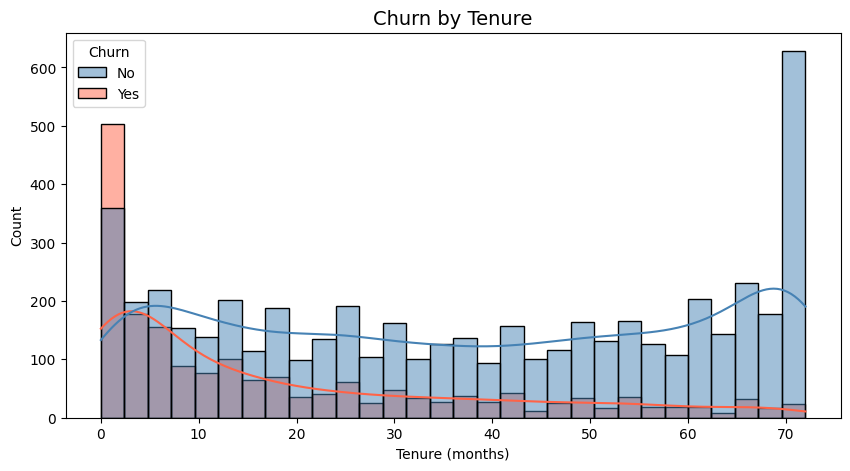

In [72]:
plt.figure(figsize=(10,5))
sns.histplot(data=data, x='tenure', hue='Churn',
             bins=30, palette=['steelblue','tomato'],
             kde=True)
plt.title('Churn by Tenure', fontsize=14)
plt.xlabel('Tenure (months)')
plt.ylabel('Count')
plt.show()

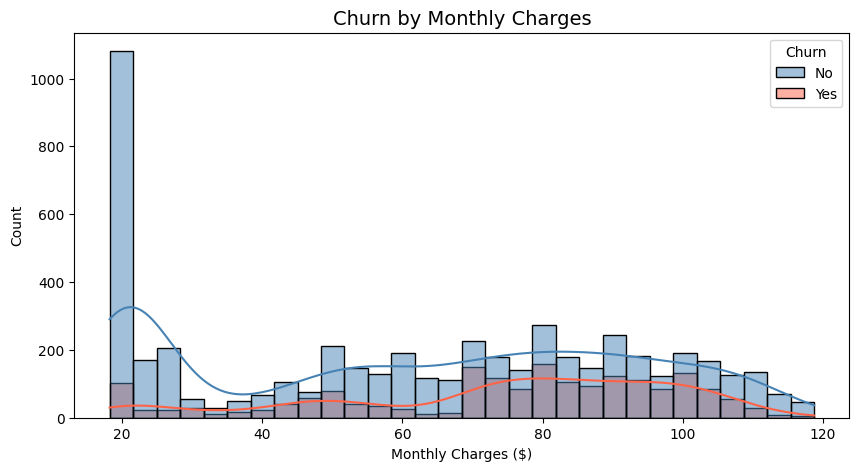

In [73]:
plt.figure(figsize=(10,5))
sns.histplot(data=data, x='MonthlyCharges', hue='Churn',
             bins=30, palette=['steelblue','tomato'],
             kde=True)
plt.title('Churn by Monthly Charges', fontsize=14)
plt.xlabel('Monthly Charges ($)')
plt.ylabel('Count')
plt.show()

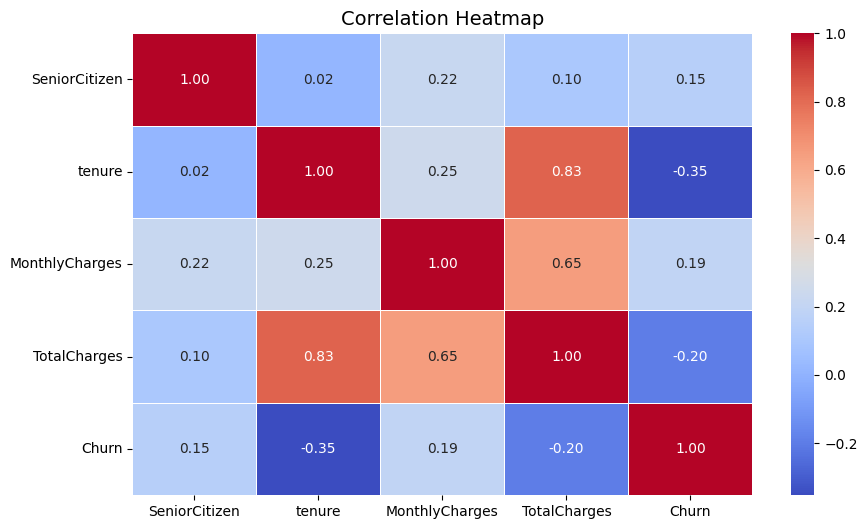

In [74]:
temp_df = data.copy()
temp_df['Churn'] = (temp_df['Churn'] == 'Yes').astype(int)
numeric_cols = temp_df.select_dtypes(include=['float64','int64'])
plt.figure(figsize=(10,6))
sns.heatmap(numeric_cols.corr(), 
            annot=True, 
            fmt='.2f',
            cmap='coolwarm',
            linewidths=0.5)
plt.title('Correlation Heatmap', fontsize=14)
plt.show()

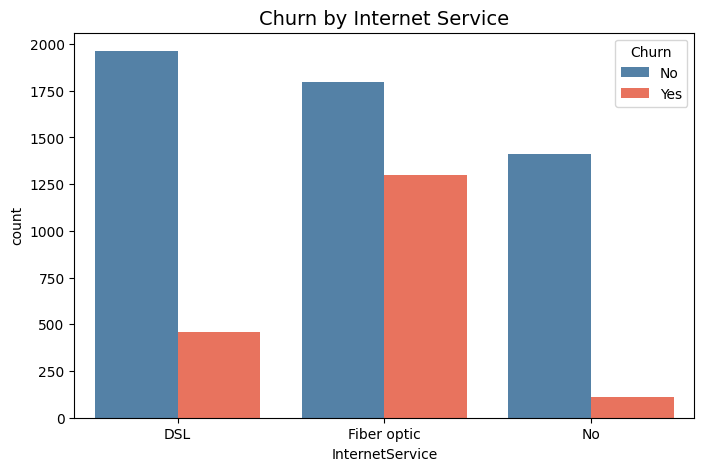

In [75]:
plt.figure(figsize=(8,5))
sns.countplot(data=data, x='InternetService', hue='Churn',
              palette=['steelblue','tomato'])
plt.title('Churn by Internet Service', fontsize=14)

plt.show()

In [76]:
data['Churn'] = data['Churn'].map({'Yes': 1, 'No': 0})
print(data['Churn'].value_counts())

Churn
0    5174
1    1869
Name: count, dtype: int64


In [77]:
x = data.drop(['Churn'],axis = 1)
y = data['Churn']

In [78]:
categorical_cols = x.select_dtypes(include=["object"]).columns
categorical_cols

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')

In [79]:
for col in categorical_cols:
    print(col, data[col].unique())

gender ['Female' 'Male']
Partner ['Yes' 'No']
Dependents ['No' 'Yes']
PhoneService ['No' 'Yes']
MultipleLines ['No phone service' 'No' 'Yes']
InternetService ['DSL' 'Fiber optic' 'No']
OnlineSecurity ['No' 'Yes' 'No internet service']
OnlineBackup ['Yes' 'No' 'No internet service']
DeviceProtection ['No' 'Yes' 'No internet service']
TechSupport ['No' 'Yes' 'No internet service']
StreamingTV ['No' 'Yes' 'No internet service']
StreamingMovies ['No' 'Yes' 'No internet service']
Contract ['Month-to-month' 'One year' 'Two year']
PaperlessBilling ['Yes' 'No']
PaymentMethod ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']


In [80]:
binary_col = ["gender", "Partner", "Dependents", "PhoneService", "PaperlessBilling"]

for col in binary_col:
    x[col] = x[col].map({"Yes" : 1, "No" : 0, "Male" :1,"Female" :0})

In [81]:
x = pd.get_dummies(x, columns=["InternetService", "Contract", "PaymentMethod","MultipleLines", "OnlineSecurity", "OnlineBackup","DeviceProtection", "TechSupport", "StreamingTV","StreamingMovies"], drop_first=True)

In [82]:
bool_cols = x.select_dtypes(include="bool").columns
x[bool_cols] = x[bool_cols].astype(int)

In [83]:
x.shape

(7043, 30)

In [84]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2)

In [85]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [86]:
from imblearn.over_sampling import SMOTE
sm = SMOTE()
x_train_sm,y_train_sm = sm.fit_resample(x_train,y_train)
print(y_train.value_counts().to_dict())
print(pd.Series(y_train_sm).value_counts().to_dict())

{0: 4148, 1: 1486}
{0: 4148, 1: 4148}


In [87]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score,classification_report,roc_auc_score)

In [88]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000,random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100,random_state=42,class_weight='balanced'),
    'XGBoost': XGBClassifier(random_state=42,eval_metric='logloss',verbosity=0)
}

In [89]:
results = {}

for name, model in models.items():
    print(f"Training: {name}")
    model.fit(x_train_sm, y_train_sm)
    y_pred = model.predict(x_test)
    y_prob = model.predict_proba(x_test)[:,1]
    acc = accuracy_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_prob)
    results[name] = {
        'model': model,
        'accuracy': acc,
        'roc_auc': roc,
        'y_pred': y_pred,
        'y_prob': y_prob
    }
    print(f"Accuracy : {acc:.4f}")
    print(f"ROC-AUC  : {roc:.4f}")
    print(f"\nClassification Report:")
    print(classification_report(y_test, y_pred))

Training: Logistic Regression
Accuracy : 0.7630
ROC-AUC  : 0.8557

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.75      0.82      1026
           1       0.54      0.81      0.65       383

    accuracy                           0.76      1409
   macro avg       0.73      0.78      0.74      1409
weighted avg       0.81      0.76      0.77      1409

Training: Random Forest
Accuracy : 0.7828
ROC-AUC  : 0.8318

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.85      0.85      1026
           1       0.60      0.60      0.60       383

    accuracy                           0.78      1409
   macro avg       0.73      0.72      0.72      1409
weighted avg       0.78      0.78      0.78      1409

Training: XGBoost
Accuracy : 0.7764
ROC-AUC  : 0.8218

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.85      